### Importação de Libs e Definições

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
# Configurações de cores para gráficos
background_color = '#111111'
text_color = '#EDEDED'
grid_color = '#6D6D6D'
primary_color = '#1B47A7'

In [3]:
base_df = pd.read_csv('dataset_desafio_series_temporais.csv')

### Análise Exploratória dos Dados

In [ ]:
base_df.head

In [ ]:
#Tipos dos Dados
base_df.dtypes

In [ ]:
#Resumo estatístico sobre a base de dados
base_df.describe()

In [ ]:
#Total de nulos 
base_df.isna().sum()

In [ ]:
# More information ...

# Para verificar se exitem variáveis duplicadas eu poderia utilizar os comandos:
# df.loc[df.duplicated()]

# E para verificar se tenho duplicados em um conjunto específico, poderia utilizar:
# df.loc[df.duplicated(subset=['column'])]

# Ler as ocorrências únicas em uma colunas: df['coluna'].unique()

# Para mudar valores em uma coluna posso usar a função .replace()
# Supondo que feriado fosse uma variável categórica, poderíamos utilizar:
# df['feriado'].replace({dicionário contendo VALOR: novo_valor_respectivo})

# Para ordenar valores, poderíamos usar: df.sort_values(by = 'coluna').head()

# Para selecionar variáveis específicas, eu poderia utilizar:
# df.loc[:, ['column1', 'column2]].sort_values(by = 'column', ascending = True/False).head(10)

In [ ]:
date = np.array(base_df['data'])
sales = np.array(base_df['vendas'])
holidays = np.array(base_df['feriado'])
campaigns = np.array(base_df['campanha_ativa'])

In [ ]:
plt.plot(date, campaigns)

plt.xlabel('x')
plt.ylabel('y')

plt.show

In [ ]:
# Plotando gráficos visuais

# Dados quantitativos: histogramas, KDE, boxplots
# Dados qualitativos: colunas, barras, pizza, linhas

In [ ]:
ax = base_df['vendas'].plot(kind='hist', bins=20)
ax.set_ylabel('Número de vendas')
ax.set_xlabel('Valor da venda')

In [ ]:
sns.boxplot(base_df['vendas'])

### Plot da Flutuação ao longo do Tempo:

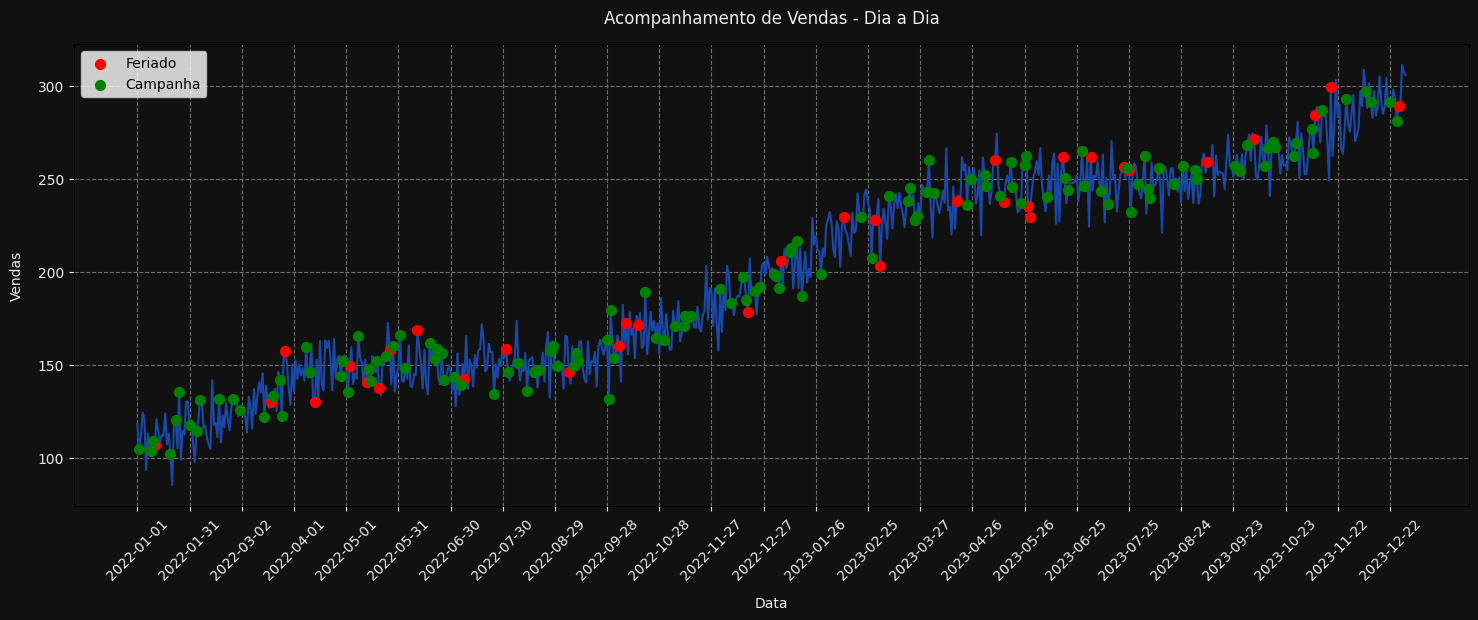

In [4]:
campanhas = base_df[base_df['campanha_ativa'] == 1]
feriados = base_df[base_df['feriado'] == 1]

plt.figure(figsize = (18, 6))
sns.lineplot(data = base_df, x = 'data', y = 'vendas', color = primary_color)

plt.scatter(feriados.index, feriados['vendas'], color='red', label='Feriado', zorder=5, s=50)
plt.scatter(campanhas.index, campanhas['vendas'], color='green', label='Campanha', zorder=5, s=50)
plt.legend()

plt.title('Acompanhamento de Vendas - Dia a Dia', color = text_color, pad = 15)
plt.xlabel('Data', color = text_color, labelpad = 10)
plt.ylabel('Vendas', color = text_color, labelpad = 10)
plt.grid(True, color = grid_color, linestyle = 'dashed')

ax = plt.gca()
ax.set_facecolor(background_color)
ax.tick_params(axis = 'x', colors = text_color)
ax.tick_params(axis = 'y', colors = text_color)
plt.xticks(base_df['data'][::30], rotation = 45)

plt.gcf().patch.set_facecolor(background_color)

In [5]:
print("Vendas médias em dias com campanha:", base_df[base_df['campanha_ativa'] == 1]['vendas'].mean())
print("Vendas médias em dias sem campanha:", base_df[base_df['campanha_ativa'] == 0]['vendas'].mean())

print("Vendas médias em dias com feriado:", base_df[base_df['feriado'] == 1]['vendas'].mean())
print("Vendas médias em dias sem feriado:", base_df[base_df['feriado'] == 0]['vendas'].mean())


Vendas médias em dias com campanha: 198.1049230769231
Vendas médias em dias sem campanha: 199.6350666666667
Vendas médias em dias com feriado: 209.92534883720933
Vendas médias em dias sem feriado: 198.70144104803492


### Decomposição da Série Temporal:

In [6]:
base_df['data'] = pd.to_datetime(base_df['data'])
base_df.set_index('data', inplace=True)

decomposicao = seasonal_decompose(base_df['vendas'], model='additive', period=365)

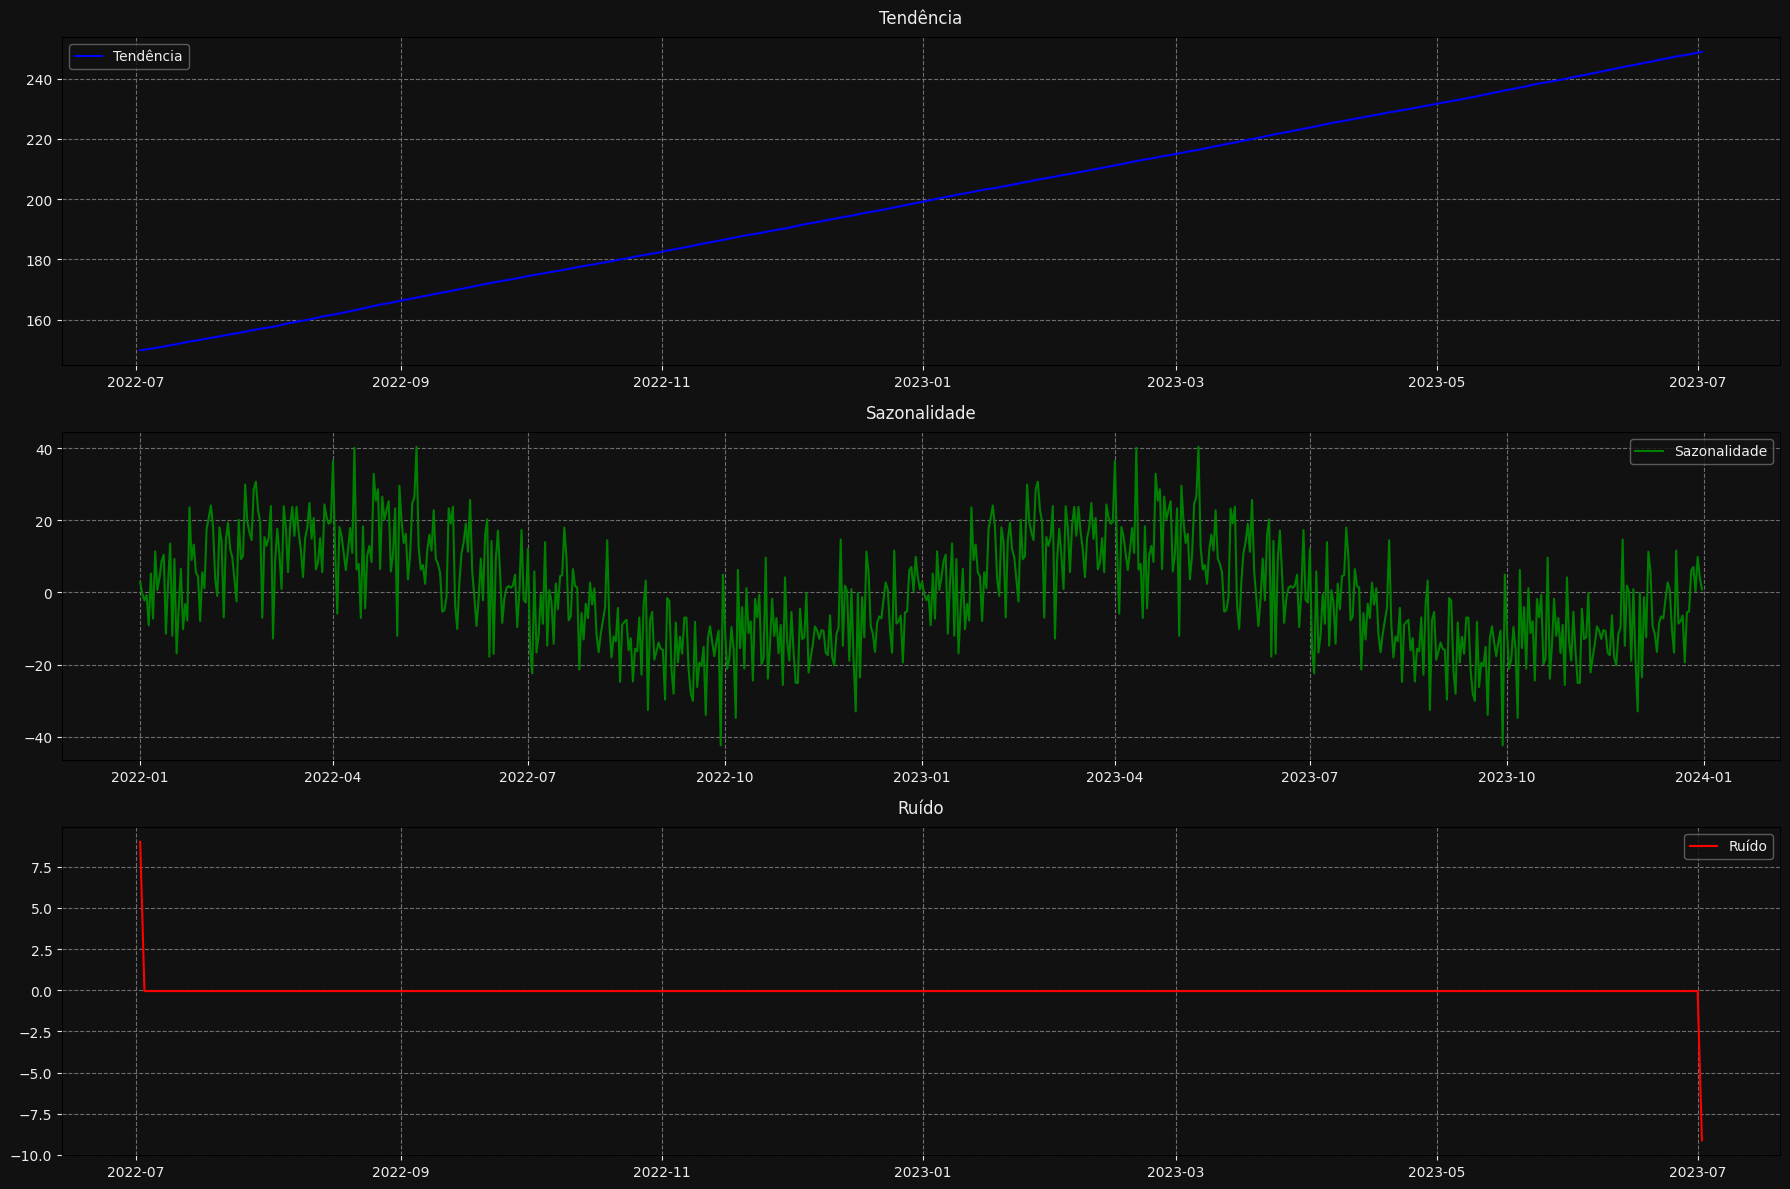

In [7]:
parameters = {
    'Tendência': [decomposicao.trend, 'blue'],
    'Sazonalidade': [decomposicao.seasonal, 'green'],
    'Ruído': [decomposicao.resid, 'red']
}

plt.figure(figsize=(18, 12))

for index, (key, value) in enumerate(parameters.items()):
    plt.subplot(3, 1, index + 1)
    plt.plot(value[0], label=key, color=value[1])
    plt.title(key, color=text_color, pad=10)
    plt.grid(True, linestyle='dashed', color=grid_color)
    plt.legend(facecolor=background_color, edgecolor=grid_color, labelcolor=text_color)
    plt.gca().set_facecolor(background_color)
    plt.tick_params(colors=text_color)

plt.tight_layout()
plt.gcf().patch.set_facecolor(background_color)
plt.show()